In [163]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import ndimage
import math

In [164]:
data_dir = "./Task-2"
image_path = os.path.join(data_dir, "AF1.jpg")

In [165]:
def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

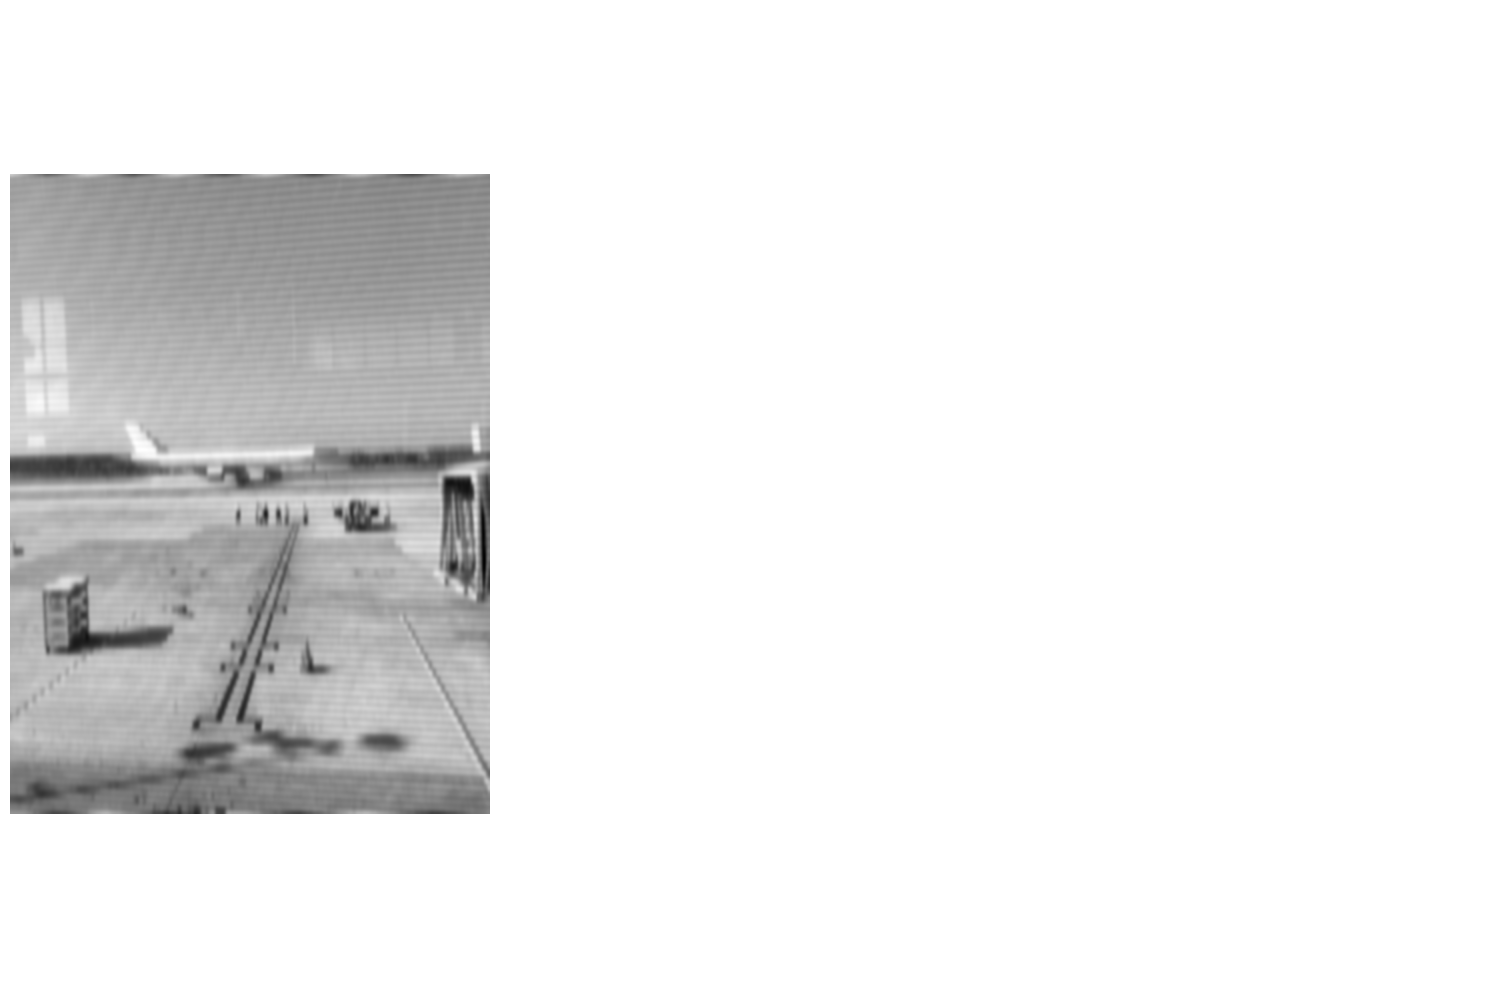

In [ ]:
import cv2
import numpy as np
from scipy import ndimage

def create_gabor_filter(ksize=31, sigma=4.0, theta=0, lambda_=10.0, gamma=0.5, psi=0):
    """
    Create a Gabor filter kernel
    
    Parameters:
    ksize: Size of the filter
    sigma: Standard deviation of the Gaussian
    theta: Orientation (0 for horizontal)
    lambda_: Wavelength of sinusoidal component
    gamma: Spatial aspect ratio
    psi: Phase offset
    """
    kernel = cv2.getGaborKernel(
        (ksize, ksize), 
        sigma, 
        theta, 
        lambda_, 
        gamma, 
        psi, 
        ktype=cv2.CV_32F
    )
    return kernel

def apply_gabor_filter(image):
    """
    Apply Gabor filter to detect horizontal structures
    """
    # Create and apply Gabor filter for horizontal line detection
    kernel = create_gabor_filter(
        ksize=37,
        sigma=3.0,
        theta=0,  # 0 degrees for horizontal
        lambda_=17.5,
        gamma=0.5
    )

    # Convert to grayscale if needed
    if len(image.shape) > 2:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    # Apply filter
    filtered = cv2.filter2D(gray, cv2.CV_32F, kernel)
    filtered = np.abs(filtered)
    
    # Normalize
    filtered = cv2.normalize(filtered, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    plot_images([filtered])
    return filtered

def analyze_blind_frequency(gabor_result):
    """
    Analyze the Gabor filter result to determine blind frequency and locations
    """
    # Sum along columns to get horizontal profile
    profile = np.sum(gabor_result, axis=1)
    
    # Find peaks in profile (blind locations)
    peaks = np.where(profile > np.mean(profile) + np.std(profile))[0]
    
    if len(peaks) > 1:
        # Estimate blind spacing
        distances = np.diff(peaks)
        avg_spacing = np.median(distances)
        return peaks, avg_spacing
    return None, None

def remove_blinds_fourier(image, gabor_result, threshold=0.8):
    """
    Remove horizontal blinds using Fourier transform with Gabor filter guidance
    
    Parameters:
    image: Input image
    gabor_result: Result from Gabor filter
    threshold: Threshold for frequency suppression (0-1)
    """
    # Convert to grayscale if needed
    if len(image.shape) > 2:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    # Analyze blind pattern
    peaks, spacing = analyze_blind_frequency(gabor_result)
    
    # Apply Fourier Transform
    f_transform = np.fft.fft2(gray)
    f_shift = np.fft.fftshift(f_transform)
    
    # Create mask
    rows, cols = gray.shape
    mask = np.ones((rows, cols), np.float32)
    center_row = rows // 2
    
    if peaks is not None and spacing is not None:
        # Convert spatial domain spacing to frequency domain
        freq_spacing = rows / spacing
        band_width = int(freq_spacing * 0.5)  # Adjust based on spacing
        
        # Create targeted suppression based on blind frequency
        for i in range(-band_width, band_width + 1):
            row = center_row + i
            if 0 <= row < rows:
                # Use Gabor response to modulate suppression strength
                gabor_strength = np.mean(gabor_result[max(0, row-1):min(rows, row+2), :])
                suppression = 1 - threshold * (gabor_strength / 255) * np.exp(-(i**2) / (2 * (band_width/3)**2))
                mask[row, :] = suppression
    else:
        # Fallback to simple horizontal frequency suppression
        band_width = int(rows * 0.05)
        for i in range(-band_width, band_width + 1):
            row = center_row + i
            if 0 <= row < rows:
                suppression = 1 - threshold * np.exp(-(i**2) / (2 * (band_width/3)**2))
                mask[row, :] = suppression
    
    # Apply mask
    f_shift_filtered = f_shift * mask
    
    # Inverse Fourier Transform
    f_ishift = np.fft.ifftshift(f_shift_filtered)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    
    # Normalize
    img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return img_back

def remove_blinds(image_path, output_path):
    """
    Main function to remove horizontal blinds from an image
    """
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Could not read image")
    
    gabor_result = apply_gabor_filter(image)

    # plot_images([gabor_result])
    
    # # Remove blinds using Fourier transform with Gabor guidance
    # result = remove_blinds_fourier(image, gabor_result, threshold=0.8)
    
    # # Enhance the result
    # result = cv2.fastNlMeansDenoising(result)
    
    # # Save result
    # cv2.imwrite(output_path, result)
    return result

# Example usage
if __name__ == "__main__":
    input_path = "input_image.jpg"
    output_path = "output_image.jpg"
    result = remove_blinds(image_path, output_path)